<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# DATA/MSML 641: Natural Language Processing
## Session 1: Word Meaning

**University of Maryland, College Park**  
**Fall 2026**  
**Instructor**: Armin Mehrabian  
**Date**: September 1, 2026


## Learning Objectives

By the end of this lecture, you will be able to:
1. Understand what constitutes a "word" and the challenges of tokenization
2. Compare different tokenization strategies (word-level, subword, BPE)
3. Apply text normalization techniques (lemmatization, stemming, case folding)
4. Distinguish between different approaches to representing word meaning
5. Understand lexicographic traditions and word sense distinctions
6. Apply decompositional and ontological approaches to semantic analysis
7. Implement word sense disambiguation techniques
8. Evaluate the strengths and limitations of traditional meaning representations

## Before we begin

**Today's focus**:
- **Word** - We've seen the complexity of defining words
- **Meaning** - What do we mean by meaning?

# Part 1: What is a Word?

Before we can talk about word *meaning*, we need to address a fundamental question: **What exactly is a word?**

This seemingly simple question has surprisingly complex answers that are crucial for NLP systems.

## Corpus Statistics: Heaps' Law and Zipf's Law

Two empirical laws describe how words are distributed in natural language.

### Heaps' Law (Vocabulary Growth)

As a corpus gets larger, the number of *distinct* word forms (types) keeps growing, but more and more slowly:

$$|V| = kN^\beta$$

- $|V|$ = vocabulary size (number of unique words/tokens)
- $N$ = corpus size (number of words/tokens)
- $k \approx 10\text{-}100$, $\beta \approx 0.4\text{-}0.6$, so $|V|$ grows **sub-linearly** in $N$

**Implication**: you will always encounter new words, but the rate of new words slows as the corpus grows.


### Zipf's Law (Frequency Distribution)

First, what is **rank**? List every word type by how often it occurs, from most frequent to least. The most frequent word has **rank 1**, the next **rank 2**, and so on. *Rank is simply a word's position in that frequency-sorted list.*

Zipf's Law says a word's frequency is inversely proportional to its rank:

$$f(r) \propto \frac{1}{r}$$

- $f(r)$ = frequency of the word at rank $r$
- So the rank-2 word appears about $1/2$ as often as the rank-1 word, the rank-3 word about $1/3$ as often, and so on.

**Example**: if the rank-1 word occurs 12,000 times, Zipf predicts roughly 6,000 for rank 2 (12,000 / 2), 4,000 for rank 3 (12,000 / 3), and 1,200 for rank 10. The demo below shows this pattern on the Brown corpus.

**Implication**: a few very frequent words account for most tokens, while most word types are rare.

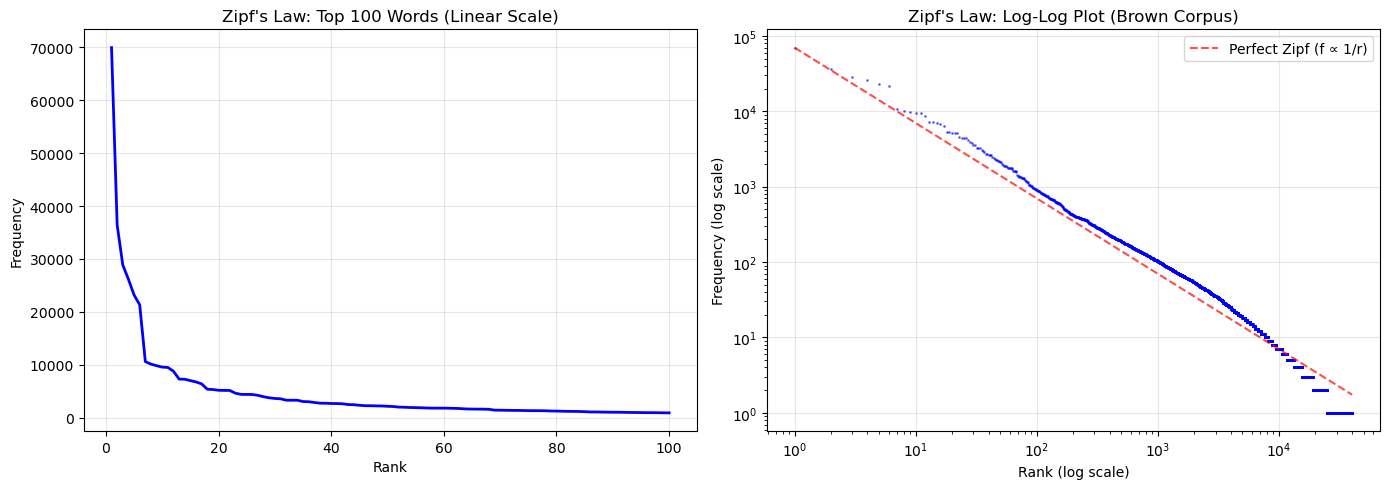


Top 10 most frequent words in Brown Corpus:
  1. 'the': 69,971 occurrences
  2. 'of': 36,412 occurrences
  3. 'and': 28,853 occurrences
  4. 'to': 26,158 occurrences
  5. 'a': 23,195 occurrences
  6. 'in': 21,337 occurrences
  7. 'that': 10,594 occurrences
  8. 'is': 10,109 occurrences
  9. 'was': 9,815 occurrences
  10. 'he': 9,548 occurrences


In [1]:
# Demo: Visualizing Zipf's Law
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import nltk

# Use Brown corpus for a realistic example
try:
    from nltk.corpus import brown
    words = [w.lower() for w in brown.words() if w.isalpha()]
except:
    nltk.download('brown')
    from nltk.corpus import brown
    words = [w.lower() for w in brown.words() if w.isalpha()]

# Count word frequencies
freq = Counter(words)
ranks = range(1, len(freq) + 1)
frequencies = [count for word, count in freq.most_common()]

# Plot Zipf's Law
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].plot(list(ranks)[:100], frequencies[:100], 'b-', linewidth=2)
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Frequency')
axes[0].set_title("Zipf's Law: Top 100 Words (Linear Scale)")
axes[0].grid(True, alpha=0.3)

# Log-log scale (should be linear if Zipf's Law holds)
axes[1].loglog(ranks, frequencies, 'b.', alpha=0.5, markersize=2)
axes[1].set_xlabel('Rank (log scale)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title("Zipf's Law: Log-Log Plot (Brown Corpus)")
axes[1].grid(True, alpha=0.3)

# Add reference line for perfect Zipf distribution
max_freq = frequencies[0]
zipf_line = [max_freq / r for r in ranks]
axes[1].loglog(ranks, zipf_line, 'r--', alpha=0.7, label='Perfect Zipf (f ∝ 1/r)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Show top words
print("\nTop 10 most frequent words in Brown Corpus:")
for rank, (word, count) in enumerate(freq.most_common(10), 1):
    print(f"  {rank}. '{word}': {count:,} occurrences")

## What Counts as a "Word"?

Defining word boundaries is surprisingly difficult:

### English Challenges

| Challenge | Example | Question |
|-----------|---------|----------|
| **Contractions** | "don't", "I'm", "we'll" | 1 token or 2? |
| **Hyphenated compounds** | "state-of-the-art", "self-driving" | 1 word or multiple? |
| **Multi-word expressions** | "New York", "ice cream" | 1 concept, multiple tokens? |
| **Clitics** | "gimme" (give me) | How to split? |
| **Numbers** | "$45.55", "3/4", "1,000,000" | One token? |
| **URLs/emails** | "https://example.com" | How many tokens? |
| **Hashtags/mentions** | "#NLProc", "@UMD" | Include punctuation? |

### No Single Right Answer

Different tokenization schemes make different choices:
- **Penn Treebank**: "don't" → "do" + "n't"
- **spaCy default**: "don't" → "do" + "n't"  
- **Simple whitespace**: "don't" → "don't" (1 token)
- **Character-level**: "don't" → "d", "o", "n", "'", "t"

## Multilingual Tokenization Challenges

Word segmentation varies dramatically across languages:

### Languages Without Spaces

| Language | Example | Challenge |
|----------|---------|-----------|
| **Chinese** | 我爱自然语言处理 | No spaces between words |
| **Japanese** | 私は自然言語処理が好きです | Mixed scripts (hiragana, katakana, kanji) |
| **Thai** | ฉันรักการประมวลผลภาษาธรรมชาติ | No word boundaries |

### Agglutinative Languages&dagger;

| Language | Example | Challenge |
|----------|---------|-----------|
| **German** | Donaudampfschifffahrtsgesellschaft | Long compound words |
| **Turkish** | evlerinizden ("from your houses") | Many morphemes per word |
| **Finnish** | talossanikinko ("in my house too?") | Complex morphology |

### Morphologically Rich Languages

- **Arabic**: Root-pattern morphology, right-to-left
- **Hebrew**: Clitics attached to words
- **Russian**: Rich inflection (case, gender, number)
- **Persian (Farsi)**: Right-to-left, and a *zero-width non-joiner* (نیم‌فاصله, "half-space") that joins morphemes inside a single word

### Featured Example: Persian (Farsi)

> آرمین، استادمان، همیشه می‌گوید درس‌هایش پنج‌دقیقه‌ای تمام می‌شوند، ولی هیچ‌وقت نمی‌شوند!

*"Armin, our instructor, always says his lectures finish in five minutes... but they never do!"*

**Why this is hard to tokenize:**
- Words like می‌گوید ("says"), می‌شوند ("become"), and هیچ‌وقت ("never") contain a **zero-width non-joiner**: it *looks* like a space on screen but is **not** a word boundary, so naive whitespace splitting mis-segments them.
- A single written word can pack many morphemes: درس‌هایش = درس ("lesson") + ها (plural) + ش ("his").
- The script runs **right-to-left**, mixing further with any embedded Latin text or numbers.

**Key Insight**: There's no universal definition of "word" across languages!

---
&dagger; **Agglutinative**: words are built by stringing together morphemes (a stem plus affixes), each marking one grammatical feature with clear boundaries. Turkish *evlerinizden* = *ev* (house) + *ler* (plural) + *iniz* (your) + *den* (from).

# Part 2: Tokenization

**Tokenization** is the process of segmenting text into tokens (words, punctuation, numbers, etc.).

It's often the **first step** in any NLP pipeline.

## Simple Tokenization Approaches

### 1. Whitespace Tokenization
```python
text.split()  # Split on whitespace
```
- **Pros**: Fast, simple
- **Cons**: Doesn't handle punctuation, contractions

### 2. Punctuation-Aware
```python
re.findall(r'\w+', text)  # Alphanumeric sequences
```
- **Pros**: Separates punctuation
- **Cons**: Splits contractions incorrectly

### 3. Rule-Based Tokenizers
- Hand-crafted rules for specific cases
- Used by NLTK, spaCy, Stanford NLP
- Handle contractions, abbreviations, URLs, etc.

### 4. Statistical/Learned Tokenizers  
- Learn segmentation from data
- Used in subword tokenization (BPE, WordPiece)

## Regular Expressions for NLP

Regular expressions (regex) are powerful tools for text pattern matching:

### Basic Patterns

| Pattern | Meaning | Example Match |
|---------|---------|---------------|
| `\w` | Word character (alphanumeric + _) | "a", "Z", "5", "_" |
| `\d` | Digit | "0", "9" |
| `\s` | Whitespace | " ", "\t", "\n" |
| `.` | Any character (except newline) | "a", "!", " " |
| `[abc]` | Character class | "a", "b", or "c" |
| `[^abc]` | Negated class | anything except a, b, c |

### Quantifiers

| Pattern | Meaning | Example |
|---------|---------|---------|
| `*` | 0 or more | `a*` matches "", "a", "aaa" |
| `+` | 1 or more | `a+` matches "a", "aaa" |
| `?` | 0 or 1 | `a?` matches "", "a" |
| `{n,m}` | n to m times | `a{2,4}` matches "aa", "aaa", "aaaa" |

### Useful NLP Patterns

```python
r'\b\w+\b'          # Word boundaries
r'[A-Z][a-z]+'      # Capitalized words
r'\d{1,3}(,\d{3})*' # Numbers with commas
r'https?://\S+'     # URLs
r'#\w+'             # Hashtags
```

In [2]:
# Demo: Why hand-writing a regex tokenizer is hard
import re

text = "Dr. Smith earned $1,234.56 in 2024! Visit https://example.com can't wait. #NLProc"
print("Text:", text)
print("=" * 70)

# Attempt 1: split on whitespace
print("\nAttempt 1  text.split()  (whitespace):")
print("  ", text.split())
# Problem: punctuation glued to words -> 'Smith', '2024!', "wait."; "can't" left whole

# Attempt 2: grab runs of word characters
print("\nAttempt 2  re.findall(r'\\w+')  (alphanumeric runs):")
print("  ", re.findall(r'\w+', text))
# Problem: '$1,234.56' shatters into ['1','234','56']; the URL splits into
#          'https','example','com'; "can't" becomes ['can','t']

# Attempt 3: patch the holes -- keep URLs, decimals, and apostrophes
pattern = r"https?://\S+|\d+(?:[.,]\d+)+|\w+(?:'\w+)?|[^\w\s]"
print("\nAttempt 3  a 'smarter' regex:")
print("  pattern:", pattern)
print("  ", re.findall(pattern, text))
# Better -- but STILL wrong: 'Dr' and '.' are split (abbreviation lost),
# '#' is separated from 'NLProc', and 'state-of-the-art' would fragment.

print("\nTakeaway: every fix adds another special case, and the next input breaks it again.")
print("Real tokenizers (NLTK, spaCy) bundle hundreds of such rules -- which is exactly why")
print("we don't hand-roll them, and why subword tokenizers learn segmentation from data.")

Text: Dr. Smith earned $1,234.56 in 2024! Visit https://example.com can't wait. #NLProc

Attempt 1  text.split()  (whitespace):
   ['Dr.', 'Smith', 'earned', '$1,234.56', 'in', '2024!', 'Visit', 'https://example.com', "can't", 'wait.', '#NLProc']

Attempt 2  re.findall(r'\w+')  (alphanumeric runs):
   ['Dr', 'Smith', 'earned', '1', '234', '56', 'in', '2024', 'Visit', 'https', 'example', 'com', 'can', 't', 'wait', 'NLProc']

Attempt 3  a 'smarter' regex:
  pattern: https?://\S+|\d+(?:[.,]\d+)+|\w+(?:'\w+)?|[^\w\s]
   ['Dr', '.', 'Smith', 'earned', '$', '1,234.56', 'in', '2024', '!', 'Visit', 'https://example.com', "can't", 'wait', '.', '#', 'NLProc']

Takeaway: every fix adds another special case, and the next input breaks it again.
Real tokenizers (NLTK, spaCy) bundle hundreds of such rules -- which is exactly why
we don't hand-roll them, and why subword tokenizers learn segmentation from data.


## Tokenization Challenges

Real-world text presents many edge cases:

### Contractions
| Input | Option A | Option B |
|-------|----------|----------|
| "don't" | "don't" | "do", "n't" |
| "I'm" | "I'm" | "I", "'m" |
| "we'll" | "we'll" | "we", "'ll" |

### Hyphenation
| Input | One token? | Multiple? |
|-------|------------|-----------|
| "state-of-the-art" | ✓ (compound) | state, of, the, art |
| "co-operate" | ✓ (prefix) | co, operate |
| "self-driving" | ✓ (compound) | self, driving |

### Special Cases
- **Abbreviations**: "U.S.A.", "Dr.", "etc."
- **Numbers**: "$3.50", "3/4", "1,000,000"
- **Dates/Times**: "2024-01-15", "3:30pm"
- **URLs**: "https://www.example.com/path?query=1"
- **Emails**: "user@domain.com"
- **Emoticons/Emoji**: ":)", "😀", "¯\\_(ツ)_/¯"

In [3]:
# Demo: Comparing NLTK and spaCy Tokenization
import nltk
import spacy

# Download NLTK tokenizer data if needed
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Test sentences with challenging cases
test_sentences = [
    "I can't believe it's not butter!",
    "Dr. Smith works at U.S.A. headquarters.",
    "The price is $19.99 (20% off).",
    "Visit https://example.com for more info.",
    "It's a state-of-the-art self-driving car.",
]

print("Comparing NLTK vs spaCy Tokenization")
print("=" * 70)

for sent in test_sentences:
    print(f"\nInput: \"{sent}\"")
    
    # NLTK tokenization
    nltk_tokens = nltk.word_tokenize(sent)
    print(f"  NLTK ({len(nltk_tokens):2d}): {nltk_tokens}")
    
    # spaCy tokenization
    doc = nlp(sent)
    spacy_tokens = [token.text for token in doc]
    print(f"  spaCy ({len(spacy_tokens):2d}): {spacy_tokens}")

Comparing NLTK vs spaCy Tokenization

Input: "I can't believe it's not butter!"
  NLTK ( 9): ['I', 'ca', "n't", 'believe', 'it', "'s", 'not', 'butter', '!']
  spaCy ( 9): ['I', 'ca', "n't", 'believe', 'it', "'s", 'not', 'butter', '!']

Input: "Dr. Smith works at U.S.A. headquarters."
  NLTK ( 7): ['Dr.', 'Smith', 'works', 'at', 'U.S.A.', 'headquarters', '.']
  spaCy ( 7): ['Dr.', 'Smith', 'works', 'at', 'U.S.A.', 'headquarters', '.']

Input: "The price is $19.99 (20% off)."
  NLTK (11): ['The', 'price', 'is', '$', '19.99', '(', '20', '%', 'off', ')', '.']
  spaCy (11): ['The', 'price', 'is', '$', '19.99', '(', '20', '%', 'off', ')', '.']

Input: "Visit https://example.com for more info."
  NLTK ( 8): ['Visit', 'https', ':', '//example.com', 'for', 'more', 'info', '.']
  spaCy ( 6): ['Visit', 'https://example.com', 'for', 'more', 'info', '.']

Input: "It's a state-of-the-art self-driving car."
  NLTK ( 7): ['It', "'s", 'a', 'state-of-the-art', 'self-driving', 'car', '.']
  spaCy (15): [

# Part 3: Subword Tokenization

Modern NLP has moved beyond word-level tokenization to **subword** approaches that handle rare words and morphology better.

## The Out-of-Vocabulary (OOV) Problem

### The Challenge

Word-level tokenization has a fundamental problem:

- **Vocabulary is fixed** at training time
- **New words** appear constantly (names, neologisms, typos)
- **Rare words** may not have enough training examples
- **Morphological variants** multiply vocabulary size

### Example

Training vocabulary: {"happy", "unhappy", "happiness", ...}

At test time: "unhappiness" → **OOV** (unknown word)

### Traditional Solutions

1. **Replace with `<UNK>`**: Loses all information
2. **Character-level models**: Very long sequences
3. **Huge vocabularies**: Memory intensive, sparse

### Modern Solution: Subword Tokenization

Split words into meaningful subword units:
- "unhappiness" → "un" + "happiness" or "un" + "happy" + "ness"
- Balances vocabulary size with sequence length

## Modern Tokenizers: A Comparison

| Model | Tokenizer | Vocab Size | Algorithm |
|-------|-----------|------------|-----------|
| **GPT-2/3/4** | BPE | 50,257 | Byte-level BPE |
| **BERT** | WordPiece | 30,522 | WordPiece |
| **RoBERTa** | BPE | 50,265 | Byte-level BPE |
| **T5** | SentencePiece | 32,000 | Unigram |
| **LLaMA** | SentencePiece | 32,000 | BPE |
| **GPT-4/Claude** | tiktoken/BPE | ~100,000 | Byte-level BPE |

### Key Observations

- **Vocabulary sizes**: 30K-100K is typical
- **Byte-level BPE**: Can encode any text (no unknown tokens)
- **Trade-off**: Larger vocab = shorter sequences but more parameters

In [4]:
# Demo: Subword Tokenization with Hugging Face Transformers
# Note: Requires 'transformers' library (pip install transformers)

try:
    from transformers import AutoTokenizer
    
    # Load different tokenizers
    tokenizers_to_compare = {
        "BERT": "bert-base-uncased",
        "GPT-2": "gpt2",
    }
    
    test_texts = [
        "Hello, world!",
        "I love natural language processing.",
        "The word 'unhappiness' is challenging.",
        "Pneumonoultramicroscopicsilicovolcanoconiosis is a long word.",
    ]
    
    print("Subword Tokenization Comparison")
    print("=" * 70)
    
    for text in test_texts:
        print(f"\nText: \"{text}\"")
        print("-" * 60)
        
        for name, model_name in tokenizers_to_compare.items():
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            tokens = tokenizer.tokenize(text)
            print(f"{name:8} ({len(tokens):2d} tokens): {tokens}")

except ImportError:
    print("Note: Install 'transformers' library to run this demo:")
    print("  pip install transformers")
    print("\nExample output would show:")
    print("  BERT: ['hello', ',', 'world', '!']")
    print("  GPT-2: ['Hello', ',', 'Ġworld', '!']")
    print("\nNote: in GPT-2 output, 'Ġ' marks a leading space, so 'Ġworld' means ' world'.")

Subword Tokenization Comparison

Text: "Hello, world!"
------------------------------------------------------------
BERT     ( 4 tokens): ['hello', ',', 'world', '!']


/Users/arminmehrabian/miniconda3/envs/gwu/lib/python3.10/site-packages/huggingface_hub-0.29.2-py3.8.egg/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.


GPT-2    ( 4 tokens): ['Hello', ',', 'Ġworld', '!']

Text: "I love natural language processing."
------------------------------------------------------------
BERT     ( 6 tokens): ['i', 'love', 'natural', 'language', 'processing', '.']
GPT-2    ( 6 tokens): ['I', 'Ġlove', 'Ġnatural', 'Ġlanguage', 'Ġprocessing', '.']

Text: "The word 'unhappiness' is challenging."
------------------------------------------------------------
BERT     (11 tokens): ['the', 'word', "'", 'un', '##ha', '##pp', '##iness', "'", 'is', 'challenging', '.']
GPT-2    (10 tokens): ['The', 'Ġword', "Ġ'", 'un', 'h', 'appiness', "'", 'Ġis', 'Ġchallenging', '.']

Text: "Pneumonoultramicroscopicsilicovolcanoconiosis is a long word."
------------------------------------------------------------
BERT     (22 tokens): ['p', '##ne', '##um', '##ono', '##ult', '##ram', '##ic', '##ros', '##copic', '##sil', '##ico', '##vo', '##lc', '##ano', '##con', '##ios', '##is', 'is', 'a', 'long', 'word', '.']
GPT-2    (20 tokens): ['P', 'neum

# Part 4: Text Normalization

**Text normalization** transforms text into a canonical form before processing.

## Is Text Normalization Still Relevant?

Short answer: **less than it used to be, but it has not disappeared.**

- **Classical NLP** normalized aggressively before processing: lowercasing, stemming, stop-word removal. The goal was to shrink the vocabulary and collapse variants.
- **Modern neural NLP (transformers, LLMs)** mostly **skips the heavy normalization.** Models train on raw, cased, punctuated text with subword tokenization, so **case and morphology carry signal** the model learns (e.g., "US" vs "us", "Apple" vs "apple"). Lowercasing or stemming would throw that information away.
- **What still matters everywhere:** light normalization such as consistent Unicode (NFC/NFKC), UTF-8 encoding, and whitespace cleanup.
- **Where the classical techniques still earn their keep:** traditional search / information retrieval, rule-based systems, classical ML baselines, and low-resource or low-compute settings.

So we cover these techniques both for those settings and to understand the pipeline historically, but keep in mind: for a typical LLM pipeline you do far less of this.

## Case Folding

**Case folding** converts text to lowercase (or uppercase) to normalize different capitalizations.

### When to Use Case Folding

| Task | Case Folding? | Why |
|------|---------------|-----|
| **Search** | Usually YES | "Apple" should match "apple" |
| **Sentiment Analysis** | Usually YES | "GREAT" = "great" |
| **Named Entity Recognition** | NO | "Apple" (company) ≠ "apple" (fruit) |
| **Machine Translation** | NO | Capitalization carries meaning |
| **Question Answering** | DEPENDS | Context matters |

### Trade-offs

**Advantages**:
- Reduces vocabulary size
- Matches variants ("iPhone" = "iphone")
- Simplifies processing

**Disadvantages**:
- Loses information (proper nouns, acronyms)
- "US" (United States) = "us" (pronoun)
- "WHO" (organization) = "who" (question word)

## Lemmatization vs. Stemming

Both reduce words to their base forms, but with different approaches:

### Stemming (Algorithmic)

- **Heuristic rules** to chop off affixes
- **Fast** but **crude**
- May produce non-words
- **Porter Stemmer** (1980) is most famous

**Examples**:
- "running" → "run"
- "runner" → "runner" (no change)
- "happily" → "happili" (not a real word!)

### Lemmatization (Dictionary-based)

- Uses **vocabulary and morphology**
- Returns actual **dictionary forms** (lemmas)
- **Slower** but **accurate**
- Requires POS tags for best results

**Examples**:
- "running" (verb) → "run"
- "running" (noun) → "running" (as in "running of the bulls")
- "better" → "good" (irregular)
- "was" → "be"

### Comparison

| Aspect | Stemming | Lemmatization |
|--------|----------|---------------|
| **Output** | May not be real words | Always real words |
| **Speed** | Fast | Slower |
| **Accuracy** | Lower | Higher |
| **POS needed** | No | Yes (for best results) |
| **Use case** | Search, IR | NLU, parsing |

In [5]:
# Demo: Lemmatization vs Stemming
import nltk
import spacy
from nltk.stem import PorterStemmer, SnowballStemmer

# Download required data
try:
    nltk.data.find('corpora/wordnet')
except:
    nltk.download('wordnet')
    nltk.download('omw-1.4')

# Initialize tools
porter = PorterStemmer()
nlp = spacy.load("en_core_web_sm")

# Test words
test_words = [
    "running", "runs", "ran",
    "better", "best", "good",
    "happily", "happiness", "happier",
    "studying", "studies", "studied",
    "geese", "goose", "mice", "mouse",
    "caring", "cared", "cares",
    "feet", "foot"
]

print("Stemming vs Lemmatization Comparison")
print("=" * 70)
print(f"{'Word':<15} {'Porter Stem':<15} {'spaCy Lemma':<15}")
print("-" * 70)

for word in test_words:
    # Porter stemming
    stem = porter.stem(word)
    
    # spaCy lemmatization
    doc = nlp(word)
    lemma = doc[0].lemma_
    
    print(f"{word:<15} {stem:<15} {lemma:<15}")

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/arminmehrabian/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/arminmehrabian/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Stemming vs Lemmatization Comparison
Word            Porter Stem     spaCy Lemma    
----------------------------------------------------------------------
running         run             run            
runs            run             run            
ran             ran             run            
better          better          well           
best            best            good           
good            good            good           
happily         happili         happily        
happiness       happi           happiness      
happier         happier         happy          
studying        studi           study          
studies         studi           study          
studied         studi           study          
geese           gees            geese          
goose           goos            goose          
mice            mice            mouse          
mouse           mous            mouse          
caring          care            care           
cared           care        

## Unicode and Text Encoding

### Why Unicode Matters for NLP

- **ASCII** (128 characters): Only English letters, digits, basic punctuation
- **Unicode** (140,000+ characters): All writing systems, emoji, symbols

### UTF-8 Encoding

- Variable-length encoding (1-4 bytes per character)
- ASCII-compatible (first 128 characters identical)
- **Standard for NLP**: Most libraries expect UTF-8

### Common Issues

| Problem | Example | Solution |
|---------|---------|----------|
| **Encoding mismatch** | "café" → "cafÃ©" | Ensure UTF-8 throughout |
| **Normalization** | "é" vs "e" + "́" | Use Unicode NFC/NFD |
| **Homoglyphs** | Latin "a" vs Cyrillic "а" | Character normalization |
| **Emoji** | "😀" = 4 bytes | Handle multi-byte correctly |

### Best Practices

```python
# Always specify encoding
with open('file.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# Normalize Unicode
import unicodedata
text = unicodedata.normalize('NFC', text)
```

## Sentence Segmentation

**Sentence segmentation** (or sentence boundary detection) splits text into sentences.

### The Challenge

Not every period ends a sentence!

| Text | Is "." a sentence boundary? |
|------|----------------------------|
| "Dr. Smith went home." | First: NO, Second: YES |
| "I paid $3.50 for it." | NO (decimal) |
| "Visit example.com today." | NO (URL) |
| "The U.S. is large." | First: NO, Second: YES |
| "What?! Really?!" | YES, YES |

### Approaches

1. **Rule-based**: Lists of abbreviations, patterns
2. **Statistical**: Trained classifiers (NLTK Punkt)
3. **Neural**: Modern NLP pipelines (spaCy, Stanza)

### spaCy Example

```python
doc = nlp("Dr. Smith earned $3.50. He was happy!")
for sent in doc.sents:
    print(sent.text)
# Output:
# Dr. Smith earned $3.50.
# He was happy!
```

## Why Word Meaning Matters: Real-World Impact

Before diving into technical approaches, let's see how word meaning representations power technologies you use every day:

### **Search & Discovery**
- **Google Search**: Uses semantic understanding to match "car repairs" with "automotive maintenance"
- **Amazon Product Search**: Finds "wireless headphones" when you search for "bluetooth earbuds"
- **Netflix Recommendations**: Understands that "sci-fi thriller" relates to specific genre preferences

### **Language Translation**
- **DeepL vs Google Translate (2024)**: Different approaches to handling ambiguous words
  - Swedish "kön" → "queue" or "gender"? Context determines meaning
  - Technical terms require specialized sense disambiguation

### **Virtual Assistants**
- **Siri/Alexa**: "Play some jazz" requires understanding music genres
- **Customer Support Bots**: Distinguish between "account balance" (financial) vs "work-life balance" (wellness)

### **Business Intelligence**
- **Social Media Analytics**: Sentiment analysis of product mentions
- **Financial News**: Extracting market-moving information from text
- **Medical Records**: Identifying symptoms and treatments from clinical notes

### Roadmap for This Lecture
To get there, we trace how the field has approached word meaning over time:
1. Historical approaches: dictionaries → ontologies → distributional vectors
2. Why **context** is essential for meaning
3. From classical semantics to **modern embeddings** (Word2Vec → LLMs)

**Today's Question**: How do we teach machines to understand word meanings as flexibly as humans do?

# What is a Word Sense?

- A **word sense** is a distinct meaning of a word.
- Dictionaries separate senses when one word can be used in **different ways**.

**Example:**  
- *bank* = financial institution  
- *bank* = side of a river  

Same word form, but different meanings depending on **context**.

---

## Why it matters in NLP

- Machines need to know which sense is intended to:  
  - Translate correctly (*pen* → enclosure vs. writing tool)  
  - Retrieve relevant information in search or QA  
  - Understand human language reliably


# Forms of Word Sense Distinction

| Category                       | Definition                                                        | Example Word | Example Senses                                                                 |
|--------------------------------|--------------------------------------------------------------------|--------------|--------------------------------------------------------------------------------|
| **Homonymy**                   | Different words that happen to share the same spelling/pronunciation | *Pen*        | - Animal enclosure<br>- Writing instrument                                     |
| **Polysemy**                   | A single word with multiple **related** meanings                  | *Bass*       | - Low register (music)<br>- Singer with low voice                              |
| **Systematic / Structured Polysemy** | A systematic alternation of senses across a category              | *Animal ↔ Food* | - chicken (animal) ↔ chicken (meat)<br>- lamb (animal) ↔ lamb (meat) |


# Word Sense Examples

| Word     | Sense 1                 | Sense 2              | Type                   |
|----------|-------------------------|----------------------|------------------------|
| bank     | financial institution   | river edge           | homonymy               |
| bark     | dog sound               | tree covering        | homonymy               |
| chicken  | bird                    | meat                 | systematic polysemy    |
| bass     | low voice / music       | fish                 | homonymy               |
| mouse    | small animal            | computer device      | polysemy               |
| turkey   | bird                    | silly person         | polysemy               |

---

**Discussion Questions**
1. Which examples are homonymy vs polysemy?  
2. Can you add more **animal ↔ food** pairs?  
3. How do we decide if senses are **related** or **coincidental**?

# Why Distinguish Homonymy, Polysemy, and Systematic Polysemy?

- **Homonymy** → completely different meanings  
  - Must treat them as separate words in modeling
- **Polysemy** → related senses  
  - Useful for generalization, often cluster in vector space
- **Systematic Polysemy** → recurring patterns across categories  
  - Systems can learn rules (e.g., animal ↔ food)

**Why it matters:**  
- Translation, search, dialogue, and knowledge graphs all rely on distinguishing these cases.


# 1. Lexicographic Approaches

## The Traditional Dictionary-Making Approach

### The Lexicographic Tradition

- **Lexicography**: The art and science of constructing dictionaries
- **Purpose**: Enumerate word meanings (senses)
- **Key Question**: What are definitions?

**Important insight**: 
> Definitions are not "defining" in the mathematical or legal sense. They are **text you read that evoke concepts in your head**.

**Example**: Legal definition of "assault"
- Intentional, affects another person with reasonable apprehension  
- Harmful or offensive contact, imminently
- Physical injury **NOT** required


### Dictionary-Making Approaches

#### **Labor-Intensive Tradition**
- **Oxford English Dictionary (OED)**: Started 1857
- **Crowdsourcing**: Volunteers found quotations for each word
- **Timeline**: More than 50 years to complete!
- **Reference**: Simon Winchester, *The Professor and the Madman*

#### **Corpus Analysis Approach**
- **Collins COBUILD Dictionary**: Published 1987
- **Method**: KWIC (Keyword in Context) analysis
- **Data-driven**: Based on actual language usage patterns

# Two Approaches to Lexicography

| Aspect               | Traditional Dictionaries (OED)                             | Corpus-Based Dictionaries (COBUILD)                    |
|-----------------------|------------------------------------------------------------|--------------------------------------------------------|
| **Method**           | Expert definitions, crowdsourced quotations                 | Real usage patterns from large text corpora             |
| **Example**          | *OED*: “Bass = lowest adult male singing voice”             | *COBUILD*: KWIC lines → “… lovely **bass** voice …”     |
| **Strengths**        | Rich historical depth, authoritative, curated               | Empirical, reflects everyday usage, adaptable to change |
| **Weaknesses**       | Labor-intensive (50+ years for OED), subjective definitions | Data-driven but may lack nuance, depends on corpus size |

---

## Key Insight

- **Traditional**: Meaning is *defined* by experts.  
- **Corpus-based**: Meaning is *discovered* from usage.  
- This shift laid the foundation for modern **distributional semantics** in NLP.


# Limits of Corpus-Based Lexicography

- **Usage ≠ Full Meaning**  
  - Shows common patterns, but not deeper connotations.
- **Rare Senses Underrepresented**  
  - Low-frequency meanings may be ignored.
- **Cultural/Subtle Nuances Lost**  
  - Stylistic notes (slang, archaic, irony) need human judgment.
- **No Built-in Interpretation**  
  - KWIC examples don’t tell you how many “senses” a word has.


In [ ]:
import nltk
nltk.download('reuters')
from nltk.corpus import reuters

# Build a text object from Reuters corpus
text = nltk.Text(reuters.words())

# Concordance for the word "bank"
text.concordance("bank", width=60, lines=8)


[nltk_data] Downloading package reuters to
[nltk_data]     /Users/arminmehrabian/nltk_data...
[nltk_data]   Package reuters is already up-to-date!


# 2. Decompositional Approaches

## Breaking Down Meaning into Components

### Lexical Decomposition Theory

**Core assumption**: Lexical meaning is complex and can be expressed in structured meaning representations

**In other words:** Word meaning is not atomic  -  it can be broken down into **structured representations**.

**Example sentence**: "Jill likes Jack most of the time"

## Components of Meaning

- **Predicates** → the main relation (e.g., *likes*)  
- **Arguments** → participants in the relation (e.g., *Jill*, *Jack*)  
- **Operators** → modifiers / scope (e.g., *what*, *most of the time*)  

---

## As a result

- Lexical decomposition assumes that meanings are **complex**  
- Structure makes meanings **compositional** and **analyzable**  
- Opens the door to formal semantic representations

# Why Decomposition Matters

### Capturing Systematic Relationships
- **"Kill"** = CAUSE (BECOME (NOT ALIVE))  
- **"Die"** = BECOME (NOT ALIVE)  
They share components but differ in causation

---

## Computational Advantages
- Understanding components → helps interpret **new combinations**
- Supports **inference**:  
  - If X kills Y → then Y dies
- Reduces the number of **primitive concepts** needed

---

## Historical Context
- Dominant view in **formal semantics (1960s–1980s)**
- Inspired by **phonology**:  
  - Sounds analyzed via features like [+voiced], [+nasal]
  - Idea: if sounds can be decomposed, maybe meanings can too


## Approach 1: Necessary and Sufficient Conditions

**Traditional approach** (Katz and Fodor):
- Idea: Word meanings can be defined by **necessary & sufficient conditions**.


**Example**: "bachelor" iff {human, male, adult, never married}

## Why this is appealing

- Provides **clear boundaries** for concepts  
- Can be expressed in formal logic  
- Useful for reasoning systems (AI, ontologies)


#### **Challenge**: Very hard to identify necessary and sufficient conditions!

**Question**: Is having four legs a necessary condition for being a dog?  
→ Does a dog that lost a leg in an accident no longer qualify as a dog? 

## But there’s a challenge...

- Many concepts resist strict definitions  
- **Dog** = {animal, four legs, barks?}  
  - What about a **three-legged dog**?  
  - Is it still a dog?

Real-world categories are often **fuzzy**, not crisply defined.

## Approach 2: Structured Conceptual Representations

### Jackendoff's Conceptual Structure Theory
> "Conceptual structure is not a part of language per se – it is a part of **thought**.  
> It is the locus for understanding linguistic utterances in context, incorporating pragmatic considerations and 'world knowledge'."

---

## Pure Lexical-Conceptual Structure (LCS)

- **Semantic primitives**: CAUSE, GO, TO, FROM, etc.
- Captures meaning in terms of **basic conceptual building blocks**

**Example: "give"**  
`give(X, Y, Z)` → `CAUSE(X, GO(Y, TO(Z)))`  
"X causes Y to go to Z" – *give* is a transfer of possession.


## Worked Example

- **Sentence**: "John gave me the book"  
- **Decomposition**:  
  - John (=X) **caused** the book (=Y) to **go**  
  - **to me** (=Z)

- Meaning is expressed as a structured conceptual representation, not just a word definition.


## Connection to Modern NLP
- Early decomposition aimed for **logical inference** → still central in AI (knowledge graphs, reasoning).  
- Modern embeddings often **rediscover similar structures** in vector space:  
  - *king – man + woman ≈ queen*  
  - Echoes the "components" idea, but **learned from data** instead of hand-coded.  
- Today: growing interest in **hybrid approaches** → combining **symbolic decomposition** (for reasoning) with **neural embeddings** (for generalization).

In [ ]:
# Demo: Lexical Conceptual Structure (LCS) Analysis

class LCSAnalyzer:
    """Simple LCS representation for verbs"""
    
    def __init__(self):
        self.verb_templates = {
            'give': 'CAUSE(X, GO(Y, TO(Z)))',
            'take': 'CAUSE(X, GO(Y, FROM(Z), TO(X)))',
            'put': 'CAUSE(X, GO(Y, TO(Z)))',
            'remove': 'CAUSE(X, GO(Y, FROM(Z)))',
            'send': 'CAUSE(X, GO(Y, TO(Z)))',
            'bring': 'CAUSE(X, GO(Y, TO(HERE)))'
        }
    
    def analyze_sentence(self, sentence, verb, arguments):
        """Analyze a sentence using LCS representation"""
        if verb.lower() in self.verb_templates:
            template = self.verb_templates[verb.lower()]
            print(f"Sentence: {sentence}")
            print(f"Verb: {verb}")
            print(f"LCS Template: {template}")
            
            if len(arguments) >= 3:
                x, y, z = arguments[0], arguments[1], arguments[2]
                instantiated = (
                    template.replace('X', x)
                            .replace('Y', y)
                            .replace('Z', z)
                )
                print("\nInstantiated Representation:")
                print(f"   {instantiated}")
                
                print("\nInterpretation:")
                print(f"   {x} caused {y} to go to {z}")
            
        else:
            print(f"No LCS template available for '{verb}'")
    
    def compare_verbs(self, verbs):
        """Compare LCS structures of multiple verbs"""
        print("LCS Comparison:")
        for verb in verbs:
            if verb in self.verb_templates:
                print(f"  {verb:8} → {self.verb_templates[verb]}")

# Create analyzer and test
lcs = LCSAnalyzer()

# Analyze example sentences
examples = [
    ("John gave Mary the book", "give", ["John", "the book", "Mary"]),
    ("Sarah took the keys from Tom", "take", ["Sarah", "the keys", "Tom"]),
    ("The robot put the box on the shelf", "put", ["The robot", "the box", "the shelf"])
]

for sentence, verb, args in examples:
    lcs.analyze_sentence(sentence, verb, args)
    print("\n" + "="*60 + "\n")

# Compare related verbs
lcs.compare_verbs(['give', 'take', 'put', 'send', 'bring'])


# 3. Word Sense Disambiguation (WSD)

## A Classic Problem in NLP

# Core Assumptions of Traditional WSD

1. **Discrete, enumerable senses**  
   - Each word has a finite, distinct set of meanings  
   - *Bank* = financial institution **or** riverbank (no in-betweens)

2. **Stable, context-independent senses**  
   - Same inventory across domains & genres  
   - *Bank₁* always = financial institution

3. **Correct sense per occurrence**  
   - Each word instance maps to exactly one "right" sense  
   - Human annotators should agree

4. **Psychological reality of senses**  
   - WordNet-like sense boundaries reflect human mental categories

5. **Explicit disambiguation is necessary**  
   - NLP must resolve ambiguity before further processing  
   - WSD seen as a crucial preprocessing step


# WSD as a Classification Problem

### Problem Formulation
- **Given**: 
  - Enumerated senses {s₁, s₂, …, sₙ} for word *w*
  - Context for *w*: (… w …)
- **Select**: the "correct" sᵢ for w




## Simple Approaches

### 1. Most Frequent Sense (MFS)
- Always assign the most common sense of the word  
- Example: "bank" → financial institution  
- **Surprisingly strong baseline** in many corpora  
- Weakness: fails badly on less common senses



### 2. Lesk Algorithm (Dictionary Overlap)
- Compare the **dictionary definitions (glosses)** of each sense with the context words  
- Pick the sense with the **largest overlap**  
- Example:  
  - Context: "The fisherman waited by the bank"  
  - *bank₁* (financial): gloss has "money, loan, institution" → no overlap  
  - *bank₂* (river): gloss has "shore, water, land" → overlaps with "fisherman, water"


### 3. Contextual Heuristics
- Use **nearby words** (collocations)  
- Example:  
  - If "money" or "loan" nearby → financial sense  
  - If "river" or "shore" nearby → geographic sense  
- Often hand-crafted rules or simple co-occurrence statistics



### 4. Knowledge-based Graph Methods
- Use ontologies like **WordNet**  
- Pick the sense that is **most related** to the senses of surrounding words  
- Graph-based scoring (e.g., PageRank over the WordNet graph)

# WSD as Supervised Classification

### Problem Setup
- **Input**: 
  - Word *w* with sense inventory {s₁, s₂, …, sₙ}  
  - Context around *w*  
- **Goal**: assign the correct sense sᵢ  

---

### Training Data
- Requires **hand-annotated corpora**  
- Example:  
  - "He deposited money in the **bank**" → financial sense  
  - "We sat by the **bank** of the river" → geographic sense  




### Supervised Classifiers
- Treat each word occurrence as a training example  
- **Features**: words in ±2 window, POS tags, collocations  
- **Labels**: sense IDs (from WordNet, etc.)  


# Example: Supervised WSD Dataset

### Word: *bank*  

| Sentence                                  | Features (context window)         | Label (Sense)            |
|-------------------------------------------|-----------------------------------|--------------------------|
| He deposited money in the **bank**        | {deposit, money, in}              | financial institution    |
| The fisherman rested by the **bank**      | {fisherman, by, river}            | river edge / shore       |
| She opened a new account at the **bank**  | {opened, account, at}             | financial institution    |
| We sat on the grassy **bank** of the river| {grassy, of, river}               | river edge / shore       |
| The **bank** approved the loan quickly    | {approved, loan, quickly}         | financial institution    |

---

### Key Points
- **Features**: words in ±2 window around *bank*  
- **Labels**: sense IDs (from WordNet or predefined inventory)  
- Each occurrence = one **training example**  
- Same framing as any supervised classification task




### Strong Baseline
- **Most Frequent Sense (MFS)**: always predict the dominant sense  
- Surprisingly competitive because sense distributions are skewed

# "I Don't Believe in Word Senses" – Kilgarriff (1997)

### The Claim
- Word senses are not real, discrete categories
- Sense inventories (WordNet, dictionaries) are **artificial constructs**
- Meaning is fluid, context-dependent, and gradient


# Distributional Approach

### Famous Motto
"You shall know a word by the company it keeps" – J.R. Firth

---

### Example: The word "bass"
- Musical sense → occurs near: *guitar, jazz, electric, play*
- Fish sense → occurs near: *lake, catch, river, striped*

Context words naturally form **clusters** that separate meanings

---

### Why It Works
- Words with similar meanings appear in **similar contexts**
- Clusters emerge from data, not from dictionary definitions
- Basis of **word embeddings** (word2vec, GloVe, fastText)

---

### Turning Context into Vectors (Preview)
Classic techniques make this idea concrete: **one-hot vectors**, **cosine similarity**, **TF-IDF**, **co-occurrence matrices**, and **PMI/PPMI** weighting. We will cover these in depth later in the course (Vector Semantics). For now, the key intuition is what matters: a word's meaning can be captured from the contexts it appears in.

# Word2Vec: Predictive Word Embeddings

### Objective
- Learn vectors by predicting **context words** given a target word
- Two main flavors:
  - Skip-gram: predict context from target
  - CBOW: predict target from context

---

### Skip-gram Objective
$$
\max_\theta \sum_{t=1}^T \sum_{-c \leq j \leq c, j \neq 0} 
\log P(w_{t+j} \mid w_t; \theta)
$$

---

Sentence: "The puppy chased the cat" (window c=2)  
- Target = "puppy"  
- Context = {the, chased, cat}  
- Model updates vectors so **puppy → close to cat/dog, not apple**

Learns embeddings via local prediction


## Summary & Key Takeaways

### **Three Approaches to Word Meaning**:

#### **1. Lexicographic**
- **Method**: Traditional dictionary-making
- **Goal**: Enumerate discrete senses with definitions  
- **Strength**: Precise, interpretable
- **Challenge**: Labor-intensive, doesn't scale well
- **Example**: Oxford English Dictionary, WordNet synsets

#### **2. Decompositional** 
- **Method**: Break meaning into semantic primitives
- **Goal**: Compositional meaning representation
- **Strength**: Systematic, captures relationships
- **Challenge**: Hard to define primitives, coverage gaps
- **Example**: LCS representations like CAUSE(X, GO(Y, TO(Z)))

#### **3. Ontological**
- **Method**: Hierarchical organization of concepts
- **Goal**: Structured knowledge with inheritance
- **Strength**: Captures relationships, enables reasoning
- **Challenge**: Coverage, agreement on hierarchies
- **Example**: WordNet taxonomy, IS-A relationships

### **Word Sense Disambiguation**
- **Problem**: Given context, choose the right sense
- **Approaches**: Most frequent sense, context analysis
- **Challenge**: Low inter-annotator agreement
- **Reality**: Many applications work around WSD rather than solving it

### **Looking Ahead**
- **Next**: How do sequences of words create meaning? (sequence models)
- **Later**: Machine learning and neural approaches to these problems
- **Later**: Distributional semantics and word embeddings (Vector Semantics)

## Next Week Preview

**Topic**: Sequential Structure in Language  
**Focus**: Hidden Markov Models, sequence labeling, and part-of-speech tagging  
**Reading**: SLP Chapters 3, 8 (through 8.4), 9, Appendices A & B

### Prepare for next week:
- Review probability and Bayes' rule
- Think about how words depend on surrounding context
- Consider: How do we model sequences in language?

---

## Discussion Questions

1. **Trade-offs**: What are the advantages and disadvantages of each approach to word meaning?

2. **Modern NLP**: Why have distributional approaches become dominant in modern NLP systems?

3. **Interpretability**: How do we balance performance with interpretability in meaning representations?

4. **Cultural aspects**: How do different approaches handle cultural and contextual variations in meaning?

5. **Future directions**: What might be the next breakthrough in computational semantics?